In [1]:
# import library & setting
import os
import time
import warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN  # hanya untuk validasi kelas manual
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances,
    adjusted_rand_score
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

METRIC = 'cosine'
N_SAMPLE = 10000   # DBSCAN manual dijalankan pada sampel agar muat di RAM Colab
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN' | Random state: 42 | N_SAMPLE: 10000


In [2]:
# load dataset
df_raw = pd.read_csv('/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()


Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [4]:
# preprocessing (sama dengan K-Means Cosine) + sampling
df = df_raw.copy()
n_awal = len(df)

df = df[df['Diabetes_012'] != 1]   # buang kelas 1 (pra-diabetes)
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

df = df.reset_index(drop=True)

y_label = df['Diabetes_012'].copy()   # label hanya untuk pembanding, tidak dipakai klastering
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

scaler = StandardScaler()
X_std = scaler.fit_transform(df_features.values)
X_norm = Normalizer(norm='l2').fit_transform(X_std)   # proyeksi ke unit hypersphere ||x|| = 1
print(f"Bentuk data siap klaster: {X_norm.shape}")
print(f"Cek norma L2 tiga baris pertama (harus 1): {np.linalg.norm(X_norm[:3], axis=1)}")

# Sampling untuk DBSCAN
rng = np.random.RandomState(RANDOM_STATE)
idx_sample = np.sort(rng.choice(len(X_norm), size=N_SAMPLE, replace=False))
X_sample = X_norm[idx_sample]
y_sample = y_label.iloc[idx_sample].reset_index(drop=True)
df_sample = df_features.iloc[idx_sample].reset_index(drop=True)
print(f"[SAMPEL] Data klastering: {X_sample.shape[0]} baris x {X_sample.shape[1]} kolom")
print(f"[SAMPEL] Sebaran label (pembanding): {y_sample.value_counts().sort_index().to_dict()}")
df_sample.head()


Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek norma L2 tiga baris pertama (harus 1): [1. 1. 1.]
[SAMPEL] Data klastering: 10000 baris x 20 kolom
[SAMPEL] Sebaran label (pembanding): {0.0: 8316, 2.0: 1684}


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,0.0,0.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,15.0,0.0,0.0,7.0,5.0
1,1.0,1.0,1.0,27.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,2.0,0.0,1.0,7.0,6.0
2,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0
3,1.0,1.0,1.0,32.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,4.0
4,0.0,0.0,0.0,24.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,10.0,0.0,0.0,0.0,6.0,3.0


[PARAM] MinPts = 40
[K-DIST] Saran eps dari siku kurva: 0.3409
[K-DIST] Persentil ke-50: 0.2483
[K-DIST] Persentil ke-75: 0.2955
[K-DIST] Persentil ke-90: 0.3384
[K-DIST] Persentil ke-95: 0.3595
[K-DIST] Persentil ke-99: 0.3922
[SIMPAN] Grafik k-distance disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN/kdistance_cosine.png'


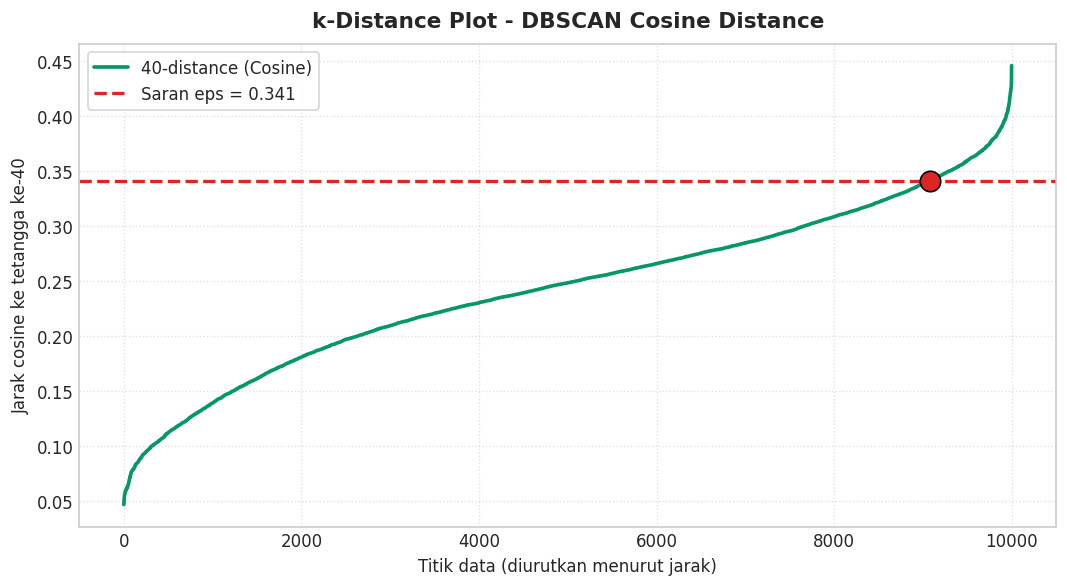

In [5]:
# k-distance plot untuk menentukan eps (pengganti Elbow Method)
MIN_PTS = 2 * X_sample.shape[1]   # heuristik: 2 x jumlah fitur
print(f"[PARAM] MinPts = {MIN_PTS}")

nbrs = NearestNeighbors(n_neighbors=MIN_PTS, metric=METRIC, algorithm='brute', n_jobs=-1).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

def find_knee_point(y_vals):
    x = np.arange(len(y_vals), dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())
    p1 = np.array([xn[0], yn[0]])
    line_unit = np.array([xn[-1], yn[-1]]) - p1
    line_unit = line_unit / np.linalg.norm(line_unit)
    pts = np.column_stack([xn, yn]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    return int(np.argmax(np.linalg.norm(pts - proj, axis=1)))

knee_idx = find_knee_point(k_dist)
eps_suggest = float(k_dist[knee_idx])
print(f"[K-DIST] Saran eps dari siku kurva: {eps_suggest:.4f}")
for q in [50, 75, 90, 95, 99]:
    print(f"[K-DIST] Persentil ke-{q}: {np.percentile(k_dist, q):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_dist, linewidth=2.2, color='#059669', label=f'{MIN_PTS}-distance (Cosine)')
plt.axhline(eps_suggest, color='#DC2626', linestyle='--', linewidth=2, label=f'Saran eps = {eps_suggest:.3f}')
plt.scatter([knee_idx], [eps_suggest], color='#DC2626', s=150, zorder=5, edgecolor='black')
plt.title('k-Distance Plot - DBSCAN Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik data (diurutkan menurut jarak)')
plt.ylabel(f'Jarak cosine ke tetangga ke-{MIN_PTS}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DIR, "kdistance_cosine.png")
plt.savefig(kdist_path, dpi=300)
print(f"[SIMPAN] Grafik k-distance disimpan ke: '{kdist_path}'")
plt.show()

In [6]:
# class DBSCAN Cosine
class DBSCANCosine:
    def __init__(self, eps=0.2, min_pts=5, chunk_size=1000):
        self.eps = eps
        self.min_pts = min_pts
        self.chunk_size = chunk_size
        self.labels_ = None
        self.core_sample_mask_ = None
        self.n_clusters_ = 0
        self.n_noise_ = 0
        self.execution_time_ = 0.0

    def _neighborhoods(self, X):
        # N_eps(p) = { q | 1 - cos(p, q) <= eps }, termasuk p sendiri; dihitung per potongan agar hemat RAM
        out = []
        for s in range(0, len(X), self.chunk_size):
            d = pairwise_distances(X[s:s + self.chunk_size], X, metric='cosine', n_jobs=-1)
            out.extend(np.where(row <= self.eps)[0].astype(np.int32) for row in d)
        return out

    def fit(self, X):
        start = time.perf_counter()
        n = X.shape[0]
        neighborhoods = self._neighborhoods(X)
        is_core = np.array([len(nb) >= self.min_pts for nb in neighborhoods])

        labels = np.full(n, -1, dtype=int)   # -1 = noise
        visited = np.zeros(n, dtype=bool)
        cluster_id = 0

        for p in range(n):
            if visited[p] or not is_core[p]:
                continue
            visited[p] = True
            labels[p] = cluster_id
            seeds = deque([p])
            while seeds:
                q = seeds.popleft()
                nb = neighborhoods[q]
                labels[nb[labels[nb] == -1]] = cluster_id          # border/core masuk klaster ini
                new_core = nb[(~visited[nb]) & is_core[nb]]        # core baru ikut diekspansi
                visited[new_core] = True
                seeds.extend(new_core.tolist())
            cluster_id += 1

        self.labels_ = labels
        self.core_sample_mask_ = is_core
        self.n_clusters_ = cluster_id
        self.n_noise_ = int(np.sum(labels == -1))
        self.execution_time_ = float(time.perf_counter() - start)
        return self

print("[INFO] Kelas DBSCANCosine berhasil diinisialisasi.")


[INFO] Kelas DBSCANCosine berhasil diinisialisasi.


In [7]:
# uji validasi terhadap DBSCAN sklearn (eps dan MinPts sama)
EPS_TEST = float(np.percentile(k_dist, 70))

mine = DBSCANCosine(eps=EPS_TEST, min_pts=MIN_PTS).fit(X_sample)
ref = DBSCAN(eps=EPS_TEST, min_samples=MIN_PTS, metric='cosine', algorithm='brute').fit(X_sample)

ref_core = np.zeros(len(X_sample), dtype=bool)
ref_core[ref.core_sample_indices_] = True

print(f"[VALIDASI] eps = {EPS_TEST:.4f} | MinPts = {MIN_PTS}")
print(f"[VALIDASI] Manual : {mine.n_clusters_} klaster, {mine.n_noise_} noise, {mine.execution_time_:.2f} detik")
print(f"[VALIDASI] sklearn: {len(set(ref.labels_)) - (1 if -1 in ref.labels_ else 0)} klaster, {int(np.sum(ref.labels_ == -1))} noise")
print(f"[VALIDASI] Core point identik : {np.array_equal(mine.core_sample_mask_, ref_core)}")
print(f"[VALIDASI] Noise identik      : {np.array_equal(mine.labels_ == -1, ref.labels_ == -1)}")
print(f"[VALIDASI] Adjusted Rand Index: {adjusted_rand_score(ref.labels_, mine.labels_):.4f}")

[VALIDASI] eps = 0.2845 | MinPts = 40
[VALIDASI] Manual : 1 klaster, 225 noise, 1.98 detik
[VALIDASI] sklearn: 1 klaster, 225 noise
[VALIDASI] Core point identik : True
[VALIDASI] Noise identik      : True
[VALIDASI] Adjusted Rand Index: 1.0000


In [8]:
# uji beberapa nilai eps
eps_candidates = sorted(set(round(float(np.percentile(k_dist, q)), 4) for q in [50, 60, 70, 80, 90, 95]) | {round(eps_suggest, 4)})
rows = []

for eps in eps_candidates:
    m = DBSCANCosine(eps=eps, min_pts=MIN_PTS).fit(X_sample)
    lab = m.labels_
    mk = lab != -1
    largest = np.bincount(lab[mk]).max() / len(lab) * 100 if m.n_clusters_ > 0 else 0.0

    if m.n_clusters_ >= 2:
        sil = silhouette_score(X_sample[mk], lab[mk], metric='cosine')
    else:
        sil = np.nan

    rows.append({
        'eps': eps,
        'Jumlah Klaster': m.n_clusters_,
        'Noise (n)': m.n_noise_,
        'Noise (%)': round(m.n_noise_ / len(lab) * 100, 2),
        'Klaster Terbesar (%)': round(largest, 2),
        'Core Point (n)': int(m.core_sample_mask_.sum()),
        'Silhouette (non-noise)': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Waktu (s)': round(m.execution_time_, 2)
    })
    print(f"[SWEEP] eps={eps} -> {m.n_clusters_} klaster, noise {m.n_noise_ / len(lab) * 100:.2f}%")

sweep_df = pd.DataFrame(rows)
print("\n" + "=" * 100)
print("TABEL UJI EPS - DBSCAN COSINE")
print("=" * 100)
print(sweep_df.to_string(index=False))

sweep_path = os.path.join(OUTPUT_DIR, "eps_sweep_cosine.csv")
sweep_df.to_csv(sweep_path, index=False)
print(f"[SIMPAN] Tabel uji eps disimpan ke: '{sweep_path}'")


[SWEEP] eps=0.2483 -> 4 klaster, noise 11.84%
[SWEEP] eps=0.2658 -> 3 klaster, noise 6.05%
[SWEEP] eps=0.2845 -> 1 klaster, noise 2.25%
[SWEEP] eps=0.3084 -> 1 klaster, noise 0.49%
[SWEEP] eps=0.3384 -> 1 klaster, noise 0.02%
[SWEEP] eps=0.3409 -> 1 klaster, noise 0.01%
[SWEEP] eps=0.3595 -> 1 klaster, noise 0.00%

TABEL UJI EPS - DBSCAN COSINE
   eps  Jumlah Klaster  Noise (n)  Noise (%)  Klaster Terbesar (%)  Core Point (n)  Silhouette (non-noise)  Waktu (s)
0.2483               4       1184      11.84                 72.09            5002                  0.0779       1.93
0.2658               3        605       6.05                 79.86            5998                  0.0920       2.37
0.2845               1        225       2.25                 97.75            6998                     NaN       2.95
0.3084               1         49       0.49                 99.51            8000                     NaN       1.97
0.3384               1          2       0.02                 99

In [9]:
# model final, evaluasi, profil klaster, simpan hasil
EPS_MANUAL = None

ok = sweep_df[(sweep_df['Jumlah Klaster'] >= 2) & (sweep_df['Noise (%)'] <= 30)]
if EPS_MANUAL is not None:
    EPS_FINAL = float(EPS_MANUAL)
elif len(ok) > 0:
    EPS_FINAL = float(ok.sort_values('Silhouette (non-noise)', ascending=False).iloc[0]['eps'])   # klaster >= 2, noise <= 30%, silhouette tertinggi
else:
    EPS_FINAL = float(eps_suggest)
print(f"[FINAL] eps = {EPS_FINAL} | MinPts = {MIN_PTS}")

model_dbscan = DBSCANCosine(eps=EPS_FINAL, min_pts=MIN_PTS).fit(X_sample)
labels = model_dbscan.labels_
mask = labels != -1
n_total = len(labels)

# Metrik dihitung pada titik non-noise (noise bukan klaster)
if model_dbscan.n_clusters_ >= 2:
    sil_score = float(silhouette_score(X_sample[mask], labels[mask], metric='cosine'))
    db_score = float(davies_bouldin_score(X_sample[mask], labels[mask]))
    ch_score = float(calinski_harabasz_score(X_sample[mask], labels[mask]))
else:
    sil_score = db_score = ch_score = np.nan

sizes = np.bincount(labels[mask]) if model_dbscan.n_clusters_ > 0 else np.array([0])

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance',
    'eps': EPS_FINAL,
    'MinPts': MIN_PTS,
    'Jumlah Data Dipakai': n_total,
    'Jumlah Fitur': X_sample.shape[1],
    'Jumlah Klaster': model_dbscan.n_clusters_,
    'Klaster >=1% data': int(np.sum(sizes >= 0.01 * n_total)),
    'Noise (n)': model_dbscan.n_noise_,
    'Noise (%)': round(model_dbscan.n_noise_ / n_total * 100, 2),
    'Core Point (n)': int(model_dbscan.core_sample_mask_.sum()),
    'Silhouette Score (non-noise) (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (non-noise) (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (non-noise) (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_dbscan.execution_time_, 5)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI DBSCAN COSINE")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

df_result = df_sample.copy()
df_result['Cluster_DBSCAN'] = labels
df_result['Diabetes_012'] = y_sample.values

profil = df_result.groupby('Cluster_DBSCAN').mean().round(3)
profil.insert(0, 'Jumlah Data', df_result.groupby('Cluster_DBSCAN').size())
profil['% Diabetes'] = df_result.groupby('Cluster_DBSCAN')['Diabetes_012'].apply(lambda s: (s == 2).mean() * 100).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_dbscan_cosine.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_dbscan_cosine.csv")
df_result.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")

[FINAL] eps = 0.2658 | MinPts = 40

TABEL EVALUASI DBSCAN COSINE
Distance Metric                          Cosine Distance
eps                                               0.2658
MinPts                                                40
Jumlah Data Dipakai                                10000
Jumlah Fitur                                          20
Jumlah Klaster                                         3
Klaster >=1% data                                      3
Noise (n)                                            605
Noise (%)                                           6.05
Core Point (n)                                      5998
Silhouette Score (non-noise) (↑)                   0.092
Davies–Bouldin Index (non-noise) (↓)              2.4929
Calinski–Harabasz Index (non-noise) (↑)            371.6
Execution Time (s) (↓)                           1.94502
[SIMPAN] Evaluasi & profil klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN/evaluasi_dbscan_cosine.xlsx'
[SIMPAN] 

In [10]:
# profil tiap klaster (label -1 = noise)
profil

,Jumlah Data,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,% Diabetes
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,
-1,605,0.512,0.433,0.957,30.094,0.562,0.056,0.127,0.560,0.478,...,0.337,3.020,7.041,7.450,0.446,0.461,7.983,4.689,0.393,19.67
0,7986,0.488,0.474,1.000,28.939,0.454,0.054,0.123,0.730,0.605,...,0.072,2.661,3.681,5.084,0.189,0.434,8.184,4.971,0.374,18.70
1,848,0.230,0.237,0.512,27.481,0.445,0.002,0.017,0.762,0.594,...,0.242,2.330,2.831,2.276,0.062,0.505,6.171,4.781,0.118,5.90
2,561,0.410,0.369,1.000,26.513,0.656,0.000,0.045,0.836,0.576,...,0.043,2.152,3.041,1.800,0.066,0.410,7.610,5.292,0.078,3.92


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN/cluster_dbscan_cosine.png'


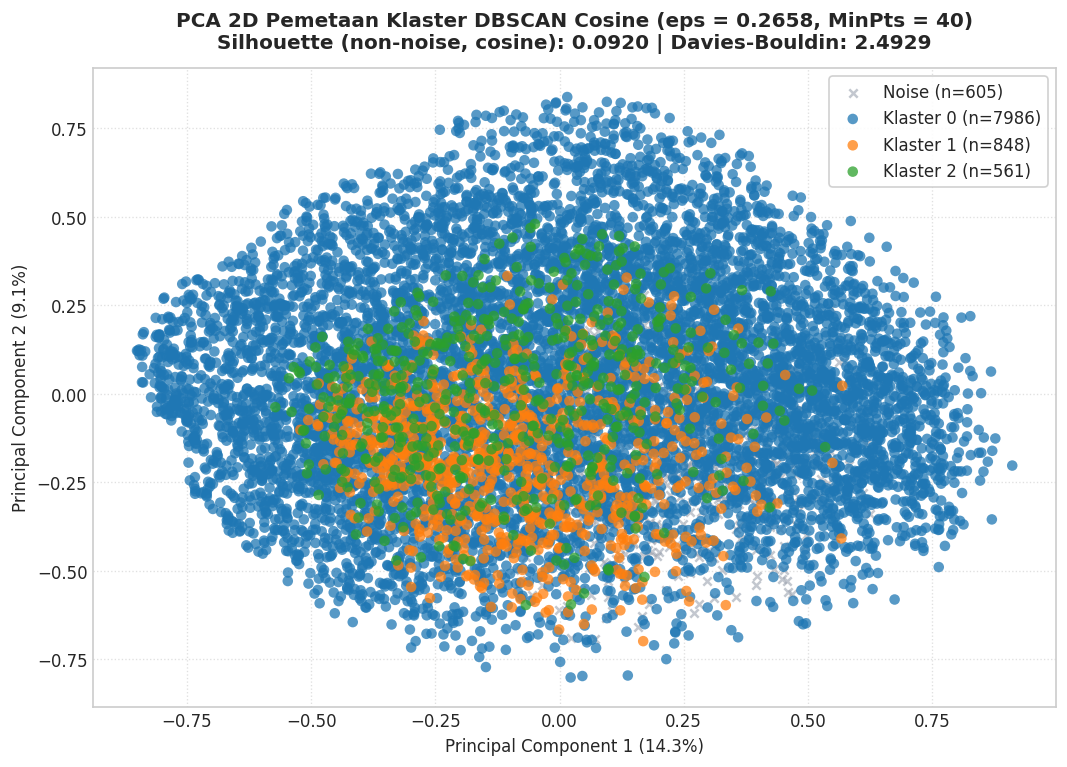

In [11]:
# visualisasi PCA 2D pemetaan klaster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(9, 6.5))
n_cl = model_dbscan.n_clusters_
palette = sns.color_palette("tab10", max(n_cl, 1))

m_noise = labels == -1
plt.scatter(X_pca[m_noise, 0], X_pca[m_noise, 1], c='#9CA3AF', marker='x', s=25, alpha=0.6,
            label=f'Noise (n={m_noise.sum()})')
for k in range(n_cl):
    mk = labels == k
    plt.scatter(X_pca[mk, 0], X_pca[mk, 1], color=palette[k], s=40, alpha=0.75, edgecolors='none',
                label=f'Klaster {k} (n={mk.sum()})')

plt.title(f'PCA 2D Pemetaan Klaster DBSCAN Cosine (eps = {EPS_FINAL}, MinPts = {MIN_PTS})\n'
          f'Silhouette (non-noise, cosine): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_dbscan_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()


In [12]:
# fitur paling berpengaruh di PC1 & PC2
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))


Fitur paling berpengaruh di PC1:
HighBP      0.405
GenHlth     0.396
DiffWalk    0.323
HighChol    0.313
Age         0.307
PhysHlth    0.264
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Fruits          0.474
Age             0.445
Veggies         0.365
HighChol        0.329
HighBP          0.318
PhysActivity    0.255
Name: PC2, dtype: float64


In [13]:
# klaster vs label diabetes (pembanding)
label_vs = pd.crosstab(df_result['Cluster_DBSCAN'], df_result['Diabetes_012'])
label_vs.columns = ['Tidak Diabetes (0)' if c == 0 else 'Diabetes (2)' for c in label_vs.columns]
label_vs['Total'] = label_vs.sum(axis=1)
if 'Diabetes (2)' in label_vs.columns:
    label_vs['Diabetes (%)'] = (label_vs['Diabetes (2)'] / label_vs['Total'] * 100).round(2)
print(f"Proporsi diabetes seluruh sampel = {(y_sample == 2).mean() * 100:.2f}%")
print(label_vs.to_string())

if model_dbscan.n_clusters_ >= 2:
    ari = adjusted_rand_score(y_sample.values[mask], labels[mask])
    print(f"\nARI klaster vs label (non-noise): {ari:.4f}")
diab_noise = int(((labels == -1) & (y_sample.values == 2)).sum())
print(f"Diabetes di noise: {diab_noise} dari {int((y_sample == 2).sum())}")

Proporsi diabetes seluruh sampel = 16.84%
                Tidak Diabetes (0)  Diabetes (2)  Total  Diabetes (%)
Cluster_DBSCAN                                                       
-1                             486           119    605         19.67
 0                            6493          1493   7986         18.70
 1                             798            50    848          5.90
 2                             539            22    561          3.92

ARI klaster vs label (non-noise): -0.0857
Diabetes di noise: 119 dari 1684
